In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg 

#### 1. Import Directory and Path Names

In [3]:
imgs = []
path = "/Users/azd/Desktop/CV - Assignment 2/image pairs"

valid_images = [".jpg",".jpeg",".png"]
lst = os.listdir(path)
lst.sort()

for f in lst:
    ext = os.path.splitext(f)[1]
    if ext.lower() not in valid_images:
        continue
    imgs.append(plt.imread(os.path.join(path,f)))

#### 2. Display Sample Images

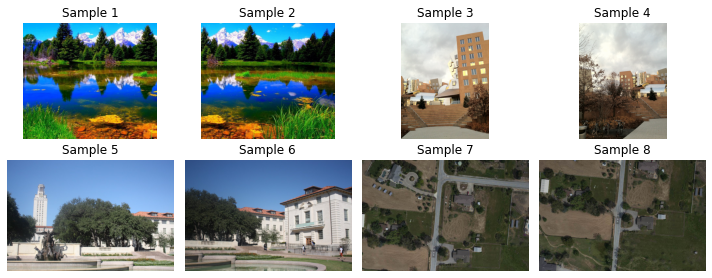

In [4]:
fig, axs = plt.subplots(2, 4,figsize=(10, 4))
for n in range(0,4):
    axs[0, n].set_title(f'Sample {n+1}')
    axs[0, n].imshow(imgs[n])
    for ax in axs.flatten():
        ax.axis('off')
for n in range(4,8):
    axs[1, n-4].set_title(f'Sample {n+1}')
    axs[1, n-4].imshow(imgs[n])
    for ax in axs.flatten():
        ax.axis('off')
plt.tight_layout()      
plt.show()

In [5]:
def harris_corner_detection(image, blockSize=2, ksize=3, k=0.04, threshold=0.01):
    # Convert image to grayscale if not already
    if len(image.shape) > 2:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image

    # Detect Harris corners
    harris_response = cv2.cornerHarris(gray, blockSize, ksize, k)

    # Normalize response values
    harris_response = cv2.normalize(harris_response, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)

    # Extract corner points above threshold and their response values
    corners = np.where(harris_response > threshold * harris_response.max())
    corners_with_response = [(x, y, harris_response[y, x]) for x, y in zip(corners[1], corners[0])]

    return corners_with_response

def adaptive_non_maximal_suppression(corners, max_corners=1000, radius=10):
    if not corners:
        return []

    # Sort corners by response value
    corners = sorted(corners, key=lambda x: x[1], reverse=True)

    # ANMS
    anms_corners = [corners[0]]
    for i, (x, y, r) in enumerate(corners):
        for j, (xj, yj, rj) in enumerate(anms_corners):
            if np.sqrt((x - xj) ** 2 + (y - yj) ** 2) < radius:
                break
        else:
            anms_corners.append((x, y, r))
        if len(anms_corners) == max_corners:
            break

    return anms_corners


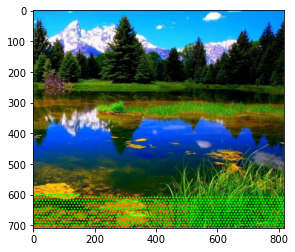

In [6]:
# Detect Harris corners
corners = harris_corner_detection(imgs[1])

# ANMS
corners = adaptive_non_maximal_suppression(corners)

# Draw corners
for (x, y, r) in corners:
    cv2.circle(imgs[1], (x, y), 3, (0, 255, 0), -1)

plt.imshow(imgs[1])